<h3>Implementing a model to classify an image into one of the 10 classes

```
kaggle download -d alessiocorrado99/animals10 --unzip -> to download the dataset.

It contains about 28K medium quality animal images belonging to 10 categories: dog, cat, horse, spyder, butterfly, chicken, sheep, cow, squirrel, elephant.

raw-img → the actual animal images (in Italian folder names like cane, gatto, etc.)
translate.py → a helper script that translates Italian folder names to English

First thing — run the translate.py script so your folders become readable English names:
bashcd LEARNING/datasets
python translate.py
```

In [1]:
import torch
from torchvision.transforms import v2
from torchvision.datasets import ImageFolder
from torch.utils.data import Subset, DataLoader
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
torch.manual_seed(42)

Structure of the code from importing libraries to training the model:
1. Imports
2. Device setup (CPU/GPU)
3. Define transforms (train and test)
4. Load dataset with ImageFolder
5. Split into train/test
6. Wrap in DataLoader
7. Visualize a batch (sanity check)
8. Define model
9. Define loss function + optimizer
10. Training loop
11. Plot loss/accuracy curves
12. Evaluate on test set


<h3>between loading and training:</h3>
<pre>

Define transforms
      ↓
ImageFolder (points to your folder, assigns labels)
      ↓
random_split (80/20)
      ↓
DataLoader (batches it up)
      ↓
Visualize one batch (make sure images + labels look correct)
      ↓
Ready to feed into model

**Importing and Loading Your Images**

PyTorch handles image loading through two main primitives: the `Dataset` and the `DataLoader`. 

*   **Using built-in datasets (`ImageFolder`):** If your images are saved in directories structured by their class labels (e.g., `folder_name/class_name/image_id.jpg`), the easiest way to import them is by using `torchvision.datasets.ImageFolder`. It automatically grabs the images, identifies unique class names, and maps them to integer labels.
*   **Building a Custom Dataset:** If your images are referenced in a custom format, like a CSV file, you must build a custom class that inherits from `torch.utils.data.Dataset`. Your custom class requires three main functions: `__init__` (to load the file paths), `__len__` (to return the total number of samples), and `__getitem__` (to load a specific image from the disk using a library like PIL/Pillow or OpenCV, apply transformations, and return it with its label).

**Preprocessing and Data Augmentation**

Before passing raw pixel data to a neural network, you must preprocess it into a standardized format. You can chain multiple preprocessing operations together using `torchvision.transforms.Compose` (or ideally, the modernized `torchvision.transforms.v2` API).

Here are the essential preprocessing steps you should apply before training:

1.  **Resizing:** Most neural networks require a fixed, uniform input size. You should use a resize transform (e.g., `Resize((224, 224))`) to ensure all images are identically shaped so they can be processed in batches. 
2.  **Converting to Tensors:** PyTorch models operate on Tensors, not raw images. You must convert your images to PyTorch Tensors and scale the pixel values from `` to `[0.0, 1.0]`. In the newest `v2` API, this is done by combining `v2.ToImage()` with `v2.ToDtype(torch.float32, scale=True)` (which replaces the deprecated `ToTensor()` transform).
3.  **Normalization:** Normalizing data helps the model learn patterns effectively by centering pixel values around zero. If you are using models pre-trained on ImageNet, you must normalize your images using the ImageNet mean `[0.485, 0.456, 0.406]` and standard deviation `[0.229, 0.224, 0.225]`.
4.  **Data Augmentation (For Training Only):** To prevent your model from overfitting (memorizing the exact training images), you should artificially increase dataset diversity by applying random transformations. Common augmentations include:
    *   **Random Flipping:** Mirrors the image horizontally or vertically so the model learns objects can appear in different orientations.
    *   **Random Cropping:** Extracts random patches of the image so the model learns that important features aren't always perfectly centered.
    *   **Color Jittering:** Randomly modifies brightness, contrast, saturation, and hue to help the model generalize across different real-world lighting conditions.

**Building the DataLoader (Optimizing the Pipeline)**

Once your `Dataset` and transformations are defined, you wrap them in a `torch.utils.data.DataLoader`. The `DataLoader` streamlines the process with three crucial features:

*   **Batching and Shuffling:** It groups your images into mini-batches so the GPU can process them in parallel, and it shuffles the data each epoch to prevent the model from learning a biased sequence.
*   **Multi-process Loading:** By setting the `num_workers` parameter to a positive integer (e.g., `num_workers=4`), the `DataLoader` uses multiple parallel subprocesses to fetch and preprocess data. This prevents data loading from bottlenecking the GPU.
*   **Memory Pinning:** Setting `pin_memory=True` places your data into page-locked CPU RAM. This avoids relying on the operating system's virtual memory and allows for significantly faster Direct Memory Access (DMA) transfers directly to the GPU's VRAM.

<h3>Device setup</h3>

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
device

'cuda'

<h3>Define transforms</h3>
transforms are operations applied to your raw data before it is fed into your model

In [4]:
#defining the pipeline
train_transforms = v2.Compose([
    #adding data augmentation
    v2.RandomRotation(45),
    v2.RandomHorizontalFlip(),
    #1. resize to fixed size
    v2.Resize((244, 244)), #standard image size for imagenet and 244 captures enough detail to classify the animals
    #2. convert to tensors and scale to [0.0, 1.0]
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale = True), #scale = True converts [0,244] -> [0,1]
    #standardize the pixel values
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) #These are the mean and std of the entire ImageNet dataset
])

test_transforms = v2.Compose([
    v2.Resize((244,244)),
    v2.ToImage(),
    v2.ToDtype(torch.float32,scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


<h3>Load the image into pytorch using ImageFolder</h3>
ImageFolder is a dataset class that assumes your images are organized in a specific way on disk. It automatically assigns labels based on folder names.

In [5]:
train_imgs = ImageFolder("../../datasets/animals10", transform=train_transforms) #.. takes you a step back
test_imgs = ImageFolder("../../datasets/animals10", transform=test_transforms)

In [6]:
train_imgs[0] #this is an object that knows where the images are, how to laod them, what labels they have, what transform to apply
#(img, label)

(Image([[[-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
         [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
         [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
         ...,
         [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
         [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
         [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179]],
 
        [[-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
         [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
         [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
         ...,
         [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
         [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
         [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357]],
 
        [[-1.8044, -1.8044, -1.8044,  ..., -1.8044, -1.8044, -1.8044],
         [-1.8044, -1.8044, -1.8044,  ..., 

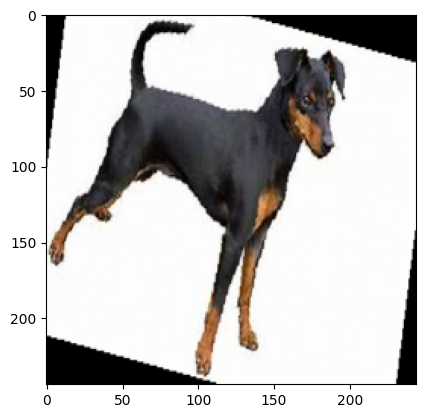

In [7]:
mean=torch.tensor([0.485, 0.456, 0.406])
std=torch.tensor([0.229, 0.224, 0.225])
index = 10
img, label = train_imgs[index] 
img = img.permute(1,2,0) *std+mean
img = img.clamp(0,1)
plt.imshow(img)

<h3>split the data into train and test</h3>

In [8]:
total_imgs = len(train_imgs)

In [9]:
labels = torch.tensor([sample[1] for sample in train_imgs.samples])

In [10]:
indices = list(range(total_imgs))

In [11]:
#stratify = labels ensures train and test sets have the SAME class distribution as the original dataset
train_indices, test_indices = train_test_split(indices, test_size=0.2, stratify=labels, random_state=42) #shuffles: (indices, labels) pairs

In [12]:
train_data = Subset(train_imgs, train_indices)
test_data = Subset(test_imgs, test_indices)

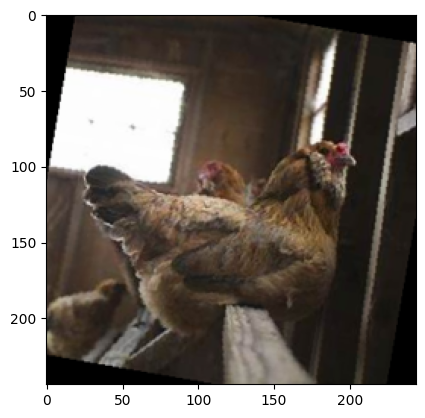

In [ ]:
index = 0
image, label = train_data[index]
image = image.permute(1,2,0) * std + mean
image = image.clamp(0,1)
plt.imshow(image)
plt.title(label)

<h3>DataLoader</h3>
->The DataLoader acts as an interface that wraps an iterable around your dataset, abstracting away the complexities of managing large datasets and ensuring your data pipeline keeps up with the model's training speed.

Here is exactly what the DataLoader does to optimize your pipeline:
* **Automatic Batching.**
* **Data Shuffling:** the DataLoader randomly rearranges the order of your data at the start of every training epoch.
* **Multi-Process Data Loading:** By setting the num_workers parameter, the DataLoader splits the data fetching tasks across multiple background subprocesses
This allows the next batches of data to be pre-fetched in parallel while the model is actively training on the current batch, preventing the GPU from waiting on slow disk reads
* **Memory Pinning:** When pin_memory=True is enabled, the DataLoader allocates your data into page-locked (pinned) memory
This prevents the operating system from swapping the data to the hard disk and allows for significantly faster Direct Memory Access (DMA) transfers straight from the CPU to the GPU
* **Data Collation:** Under the hood, the DataLoader uses a collate_fn (collate function) to merge a list of individual data samples into a properly formatted batch
It automatically prepends a batch dimension to your arrays and converts them into PyTorch Tensors



In [14]:
train_loader = DataLoader(train_data,
                          batch_size= 48,
                          shuffle=True,
                          pin_memory=True,
                          num_workers=0)

test_loader = DataLoader(test_data,
                         batch_size= 48,
                         shuffle=True,
                         num_workers=0,
                         pin_memory=True)

In [15]:
def model_architecture():
    weights = ResNet18_Weights.DEFAULT
    model = resnet18(weights=weights)

    num_filters = model.fc.in_features

    model.fc = nn.Sequential(
        nn.Linear(num_filters, 256),
        nn.ReLU(),
        nn.Linear(256, 10)
    ) #model.fc overwrites the original fc layer

    model = model.to(device)
    return model

<h3>Important note about the outputs tensor:</h3>

```
During the training phase, PyTorch actively records every operation performed on tensors into a "computational graph" so that it can later calculate the gradients during the backward pass (loss.backward()). Therefore, the model output tensor carries both the prediction numbers and a tracking history (the grad_fn).
```

In [16]:

torch.tensor(labels.size())

tensor([26179])

In [22]:
model = model_architecture()

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

num_epochs = 1

for epoch in range(num_epochs):
    running_loss = 0.0 #loss over one epoch
    correct_train = 0 #number of examples model got right in one epoch
    total_train = 0 #number of training examples in one epoch

    model.train()

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() #here item extracts raw number from single valued tensor 

        predictions = torch.argmax(outputs, dim=1) #max of each row

        total_train += labels.size(0)
        correct_train += (predictions == labels).sum().item()

    train_accuracy = 100 * correct_train / total_train

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Loss: {running_loss/len(train_loader):.4f} "
          f"Accuracy: {train_accuracy:.2f}%")

Epoch [1/1] Loss: 0.6753 Accuracy: 81.55%


In [18]:
model.eval()

correct_test = 0
total_test = 0
test_loss = 0
with torch.inference_mode():
    for img, label in test_loader:
        imgs = img.to(device)
        labels = label.to(device)
        
        logits = model(imgs)
        outputs = torch.argmax(logits, dim = 1)
        
        test_loss += criterion(logits, labels).item()
        
        total_test += labels.size(0)
        correct_test += (outputs == labels).sum().item()
        
    test_acc = 100 * correct_test / total_test
    print(f"test accuracy = {test_acc:.2f}%")
    print(f"test loss = {test_loss/len(test_loader):.2f}")


test accuracy = 96.50%
test loss = 0.12


<pre>
without data augmentation -> train_accuracy = 99.32% and test_accuracy = 96.89%
with data augmentation -> train_accuracy = 96.19% and test_accuracy = 96.50%

In [21]:
torch.save(model.state_dict, "../../saved_models/animal10.pth")